# 00b — Pedestrian Priority Score

Appends OSM-derived pedestrian-vs-car space features to the existing augmented CSV.
**Existing columns are never recomputed or overwritten.**

**Input:** `csv/features_all_boroughs_with_location_id_augmented.csv`  
**Output:** `csv/features_all_boroughs_with_location_id_augmented.csv` (updated in-place)

### New columns

| Column | Description |
|---|---|
| `sidewalk_score` | 1.0 = both sides, 0.5 = one side / unknown, 0.0 = none |
| `cycleway_score` | 1.0 if any cycle infrastructure present, else 0.0 |
| `speed_score` | 1.0 ≤ 20 mph → 0.0 > 40 mph (pedestrian comfort proxy) |
| `lane_penalty` | Normalised lane count (0–1, higher = more car lanes) |
| `highway_type_score` | 1.0 = pedestrian/living_street → 0.0 = motorway/trunk |
| `pedestrian_priority_score` | Composite PPS = weighted sum of above (0–1, higher = more pedestrian-friendly) |

### Method
For each segment in the CSV, the notebook:
1. Fetches the OSM drivable + walkable street graph for the borough (cached).
2. Finds the nearest OSM edge to the segment midpoint via a fast spatial index.
3. Extracts raw OSM tags (`sidewalk`, `cycleway`, `maxspeed`, `lanes`, `highway`).
4. Scores and combines them into `pedestrian_priority_score`.

In [1]:
import sys
from pathlib import Path

repo_root = Path('..').resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import osmnx as ox
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point
from scipy.spatial import cKDTree
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

ox.settings.log_console = False
ox.settings.use_cache = True

In [8]:
# ── Paths ─────────────────────────────────────────────────────────────────────
REPO_ROOT = Path('..').resolve()
CSV_DIR   = REPO_ROOT / 'csv'
INPUT_CSV = CSV_DIR / 'features_all_boroughs_with_location_id_augmented.csv'
OUTPUT_CSV = CSV_DIR / 'features_all_boroughs_with_location_id_augmented_pps.csv'
CRS_PROJECTED = 'EPSG:27700'

# ── Borough definitions (identical to 00_DataFetching.ipynb) ──────────────────
BOROUGHS = {
    'westminster':   'City of Westminster, London, UK',
    'islington':     'London Borough of Islington, London, UK',
    'hackney':       'London Borough of Hackney, London, UK',
    'tower_hamlets': 'London Borough of Tower Hamlets, London, UK',
    'southwark':     'London Borough of Southwark, London, UK',
}

ALLOWED_BOROUGH_NAMES = list(BOROUGHS.values())

# ── Score weights ─────────────────────────────────────────────────────────────
# Must sum to 1.0.  Adjust to reflect your research priorities.
WEIGHTS = {
    'sidewalk_score':     0.30,
    'cycleway_score':     0.15,
    'speed_score':        0.20,
    'lane_penalty_inv':   0.20,   # (1 - lane_penalty) so more lanes → lower PPS
    'highway_type_score': 0.15,
}
assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-9, 'Weights must sum to 1.0'

# Max lanes used for normalisation (lanes > MAX_LANES are clipped)
MAX_LANES = 6

# OSM network type to fetch — 'all' captures pedestrian, cycle, and car edges
NETWORK_TYPE = 'all'

# ── Speed lookup (mph → score) ────────────────────────────────────────────────
SPEED_SCORE_MAP = {
    20:  1.00,
    30:  0.75,
    40:  0.40,
    50:  0.20,
    60:  0.10,
    70:  0.00,
}

# ── Highway-type score (higher = more pedestrian-friendly) ────────────────────
HIGHWAY_SCORE_MAP = {
    'pedestrian':    1.00,
    'living_street': 1.00,
    'footway':       1.00,
    'path':          0.90,
    'cycleway':      0.85,
    'residential':   0.75,
    'service':       0.65,
    'unclassified':  0.60,
    'tertiary':      0.45,
    'tertiary_link': 0.45,
    'secondary':     0.30,
    'secondary_link':0.30,
    'primary':       0.15,
    'primary_link':  0.15,
    'trunk':         0.05,
    'trunk_link':    0.05,
    'motorway':      0.00,
    'motorway_link': 0.00,
}

In [16]:
# ── Loaders ───────────────────────────────────────────────────────────────────
def load_augmented_features(csv_path):
    """Load the augmented feature CSV and attach projected geometry.
    Only rows whose `borough` is in ALLOWED_BOROUGH_NAMES are kept."""
    df = pd.read_csv(csv_path)
    if 'geometry' not in df.columns:
        raise ValueError(f'Missing geometry column in {csv_path}')
    if 'borough' in df.columns:
        df = df[df['borough'].isin(ALLOWED_BOROUGH_NAMES)].reset_index(drop=True)
    geometry = gpd.GeoSeries.from_wkt(df['geometry'], crs=CRS_PROJECTED)
    df = df.drop(columns='geometry')
    return gpd.GeoDataFrame(df, geometry=geometry, crs=CRS_PROJECTED)


def fetch_osm_edges(borough_query):
    """Return a projected GeoDataFrame of OSM edges with pedestrian-relevant tags."""
    print(f'  Fetching OSM street graph (network_type={NETWORK_TYPE!r}, cached)...')
    G = ox.graph_from_place(borough_query, network_type=NETWORK_TYPE)
    edges = ox.graph_to_gdfs(G, nodes=False, edges=True)
    edges = edges.to_crs(CRS_PROJECTED)

    # Keep only the columns we need (others may be list-typed and cause issues)
    keep = ['geometry', 'highway', 'lanes', 'maxspeed', 'sidewalk', 'cycleway', 'width', 'oneway']
    existing = [c for c in keep if c in edges.columns]
    edges = edges[existing].copy()

    # Flatten list-typed OSM tag columns to their first element
    for col in ['highway', 'sidewalk', 'cycleway', 'maxspeed', 'lanes']:
        if col in edges.columns:
            edges[col] = edges[col].apply(
                lambda v: v[0] if isinstance(v, list) else v
            )

    print(f'  {len(edges):,} OSM edges loaded.')
    return edges.reset_index(drop=True)

In [17]:
# ── Nearest-edge matching ─────────────────────────────────────────────────────
def build_edge_index(edges_gdf):
    """Build a cKDTree of edge midpoints for fast nearest-neighbour lookup."""
    midpoints = edges_gdf.geometry.apply(
        lambda g: g.interpolate(0.5, normalized=True)
        if g.geom_type in ('LineString', 'MultiLineString')
        else g.centroid
    )
    coords = np.array([(p.x, p.y) for p in midpoints])
    return cKDTree(coords)


def match_segments_to_edges(segments_gdf, edges_gdf, tree):
    """For each segment return the index of the nearest OSM edge."""
    seg_midpoints = segments_gdf.geometry.apply(
        lambda g: g.interpolate(0.5, normalized=True)
        if g.geom_type in ('LineString', 'MultiLineString')
        else g.centroid
    )
    seg_coords = np.array([(p.x, p.y) for p in seg_midpoints])
    _, indices = tree.query(seg_coords)
    return indices

In [18]:
# ── Scoring functions ─────────────────────────────────────────────────────────
def score_sidewalk(val):
    """Score sidewalk OSM tag.
    'both' → 1.0 | 'left'/'right'/'yes' → 0.5 | 'no'/'none' → 0.0 | NaN → 0.5
    """
    if pd.isna(val):
        return 0.5   # unknown → neutral
    v = str(val).strip().lower()
    if v == 'both':
        return 1.0
    if v in ('left', 'right', 'yes', 'separate'):
        return 0.5
    if v in ('no', 'none'):
        return 0.0
    return 0.5   # unrecognised tag → neutral


def score_cycleway(val):
    """1.0 if any cycle infrastructure tag is present, 0.0 if explicitly absent, 0.2 if unknown."""
    if pd.isna(val):
        return 0.2   # absence of tag ≠ confirmed absence of cycle lane
    v = str(val).strip().lower()
    if v in ('no', 'none', 'share_busway'):
        return 0.0
    # Any explicit cycleway value (lane, track, shared_lane, opposite, …)
    return 1.0


def score_speed(val):
    """Parse maxspeed string and return pedestrian comfort score."""
    if pd.isna(val):
        return 0.5   # unknown → mid score
    v = str(val).strip().lower()
    # Handle special OSM values
    if v in ('walk', 'living_street'):
        return 1.0
    if v in ('national', 'signals', 'variable'):
        return 0.25
    # Strip 'mph' or 'km/h' suffix and convert
    try:
        if 'mph' in v:
            speed_mph = float(v.replace('mph', '').strip())
        elif 'km' in v:
            speed_mph = float(v.replace('km/h', '').replace('kmh', '').strip()) * 0.621371
        else:
            # OSM default in the UK is mph; bare numbers in London are mph
            speed_mph = float(v)
    except ValueError:
        return 0.5

    # Interpolate between breakpoints
    breakpoints = sorted(SPEED_SCORE_MAP.items())   # [(20,1.0),(30,0.75),...]
    if speed_mph <= breakpoints[0][0]:
        return breakpoints[0][1]
    if speed_mph >= breakpoints[-1][0]:
        return breakpoints[-1][1]
    for (lo_speed, lo_score), (hi_speed, hi_score) in zip(breakpoints, breakpoints[1:]):
        if lo_speed <= speed_mph <= hi_speed:
            t = (speed_mph - lo_speed) / (hi_speed - lo_speed)
            return round(lo_score + t * (hi_score - lo_score), 4)
    return 0.5


def score_lanes(val):
    """Normalise lane count to [0, 1] penalty (higher = more car space)."""
    if isinstance(val, (list, tuple, np.ndarray, pd.Series)):
        val = val[0] if len(val) else np.nan
    if pd.isna(val):
        return 0.5   # unknown → mid penalty
    try:
        text = str(val).strip()
        if ';' in text:
            text = text.split(';', 1)[0].strip()
        if text.startswith('[') and text.endswith(']'):
            text = text.strip('[]').split(',')[0].strip().strip("'\"")
        n = float(text)
    except (ValueError, TypeError):
        return 0.5
    return round(float(np.clip(n, 1, MAX_LANES) - 1) / (MAX_LANES - 1), 4)


def score_highway(val):
    """Look up highway type in HIGHWAY_SCORE_MAP; default 0.5 for unknowns."""
    if pd.isna(val):
        return 0.5
    v = str(val).strip().lower()
    return HIGHWAY_SCORE_MAP.get(v, 0.5)


def compute_pps(sidewalk, cycleway, speed, lane_penalty, highway):
    """Combine sub-scores into Pedestrian Priority Score."""
    return round(
        WEIGHTS['sidewalk_score']     * sidewalk
        + WEIGHTS['cycleway_score']   * cycleway
        + WEIGHTS['speed_score']      * speed
        + WEIGHTS['lane_penalty_inv'] * (1.0 - lane_penalty)
        + WEIGHTS['highway_type_score'] * highway,
        4,
    )

In [19]:
# ── Per-borough enrichment ────────────────────────────────────────────────────
def enrich_borough(segments_gdf, borough_query):
    """Match segments to OSM edges and compute pedestrian sub-scores + PPS."""
    edges = fetch_osm_edges(borough_query)
    tree  = build_edge_index(edges)
    idx   = match_segments_to_edges(segments_gdf, edges, tree)
    matched = edges.iloc[idx].reset_index(drop=True)

    result = segments_gdf.copy()
    result['sidewalk_score']     = matched['sidewalk'].apply(score_sidewalk).values   if 'sidewalk'  in matched.columns else 0.5
    result['cycleway_score']     = matched['cycleway'].apply(score_cycleway).values   if 'cycleway'  in matched.columns else 0.2
    result['speed_score']        = matched['maxspeed'].apply(score_speed).values      if 'maxspeed'  in matched.columns else 0.5
    result['lane_penalty']       = matched['lanes'].apply(score_lanes).values         if 'lanes'     in matched.columns else 0.5
    result['highway_type_score'] = matched['highway'].apply(score_highway).values     if 'highway'   in matched.columns else 0.5

    result['pedestrian_priority_score'] = [
        compute_pps(sw, cy, sp, lp, hw)
        for sw, cy, sp, lp, hw in zip(
            result['sidewalk_score'],
            result['cycleway_score'],
            result['speed_score'],
            result['lane_penalty'],
            result['highway_type_score'],
        )
    ]
    return result

In [20]:
# ── Main enrichment loop ──────────────────────────────────────────────────────
NEW_COLS = [
    'sidewalk_score', 'cycleway_score', 'speed_score',
    'lane_penalty', 'highway_type_score', 'pedestrian_priority_score',
]

base_features = load_augmented_features(INPUT_CSV)
base_features['_row_order'] = np.arange(len(base_features))

# Skip columns that already exist (idempotency guard)
cols_to_add = [c for c in NEW_COLS if c not in base_features.columns]
if not cols_to_add:
    print('All PPS columns already present — nothing to do.')
else:
    print(f'Columns to add: {cols_to_add}')
    for col in cols_to_add:
        base_features[col] = np.nan

    for borough_name, borough_features in base_features.groupby('borough', sort=False):
        if borough_name not in ALLOWED_BOROUGH_NAMES:
            print(f'\n[WARNING] Skipping unrecognised borough: {borough_name!r}')
            continue

        print(f'\n══ {borough_name.upper()} ══')
        enriched = enrich_borough(borough_features, borough_name)

        for col in cols_to_add:
            base_features.loc[enriched.index, col] = enriched[col].values

    base_features = base_features.sort_values('_row_order').drop(columns='_row_order')

    # Serialise geometry back to WKT before saving
    if 'geometry' in base_features.columns:
        base_features['geometry'] = base_features.geometry.to_wkt()

    OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
    base_features.to_csv(OUTPUT_CSV, index=False)
    print(f'\nSaved → {OUTPUT_CSV.name}  ({len(base_features):,} rows)')

Columns to add: ['sidewalk_score', 'cycleway_score', 'speed_score', 'lane_penalty', 'highway_type_score', 'pedestrian_priority_score']

══ LONDON BOROUGH OF ISLINGTON, LONDON, UK ══
  Fetching OSM street graph (network_type='all', cached)...
  32,382 OSM edges loaded.

══ LONDON BOROUGH OF TOWER HAMLETS, LONDON, UK ══
  Fetching OSM street graph (network_type='all', cached)...
  63,720 OSM edges loaded.

══ LONDON BOROUGH OF HACKNEY, LONDON, UK ══
  Fetching OSM street graph (network_type='all', cached)...
  38,333 OSM edges loaded.

══ LONDON BOROUGH OF SOUTHWARK, LONDON, UK ══
  Fetching OSM street graph (network_type='all', cached)...
  63,026 OSM edges loaded.

══ CITY OF WESTMINSTER, LONDON, UK ══
  Fetching OSM street graph (network_type='all', cached)...
  63,482 OSM edges loaded.

Saved → features_all_boroughs_with_location_id_augmented_pps.csv  (35,978 rows)


In [21]:
# ── Validation summary ────────────────────────────────────────────────────────
print('\n── PPS column summary ──')
if OUTPUT_CSV.exists():
    df = pd.read_csv(OUTPUT_CSV)
    print(f'Loaded {len(df):,} rows from {OUTPUT_CSV.name}')
    available = [c for c in NEW_COLS if c in df.columns]
    print('\nDescriptive statistics:')
    print(df[available].describe().T[['count', 'mean', 'min', 'max']].to_string())
    nan_pct = df[available].isna().mean().mul(100).round(1)
    print('\nMissing values (%): ')
    print(nan_pct.to_string())
    print('\nPPS distribution by borough:')
    if 'borough' in df.columns and 'pedestrian_priority_score' in df.columns:
        print(df.groupby('borough')['pedestrian_priority_score']
              .agg(['mean', 'min', 'max'])
              .round(3)
              .to_string())
else:
    print(f'{OUTPUT_CSV} not found')


── PPS column summary ──
Loaded 35,978 rows from features_all_boroughs_with_location_id_augmented_pps.csv

Descriptive statistics:
                             count      mean     min   max
sidewalk_score             35978.0  0.500000  0.5000  0.50
cycleway_score             35978.0  0.200000  0.2000  0.20
speed_score                35978.0  0.869971  0.2000  1.00
lane_penalty               35978.0  0.447876  0.0000  1.00
highway_type_score         35978.0  0.667091  0.0500  1.00
pedestrian_priority_score  35978.0  0.564482  0.3375  0.73

Missing values (%): 
sidewalk_score               0.0
cycleway_score               0.0
speed_score                  0.0
lane_penalty                 0.0
highway_type_score           0.0
pedestrian_priority_score    0.0

PPS distribution by borough:
                                              mean    min    max
borough                                                         
City of Westminster, London, UK              0.566  0.388  0.708
London Bor

Loaded 35,978 PPS rows from features_all_boroughs_with_location_id_augmented_pps.csv


,count,mean,min,max
pedestrian_priority_score,35978.0,0.564482,0.3375,0.73


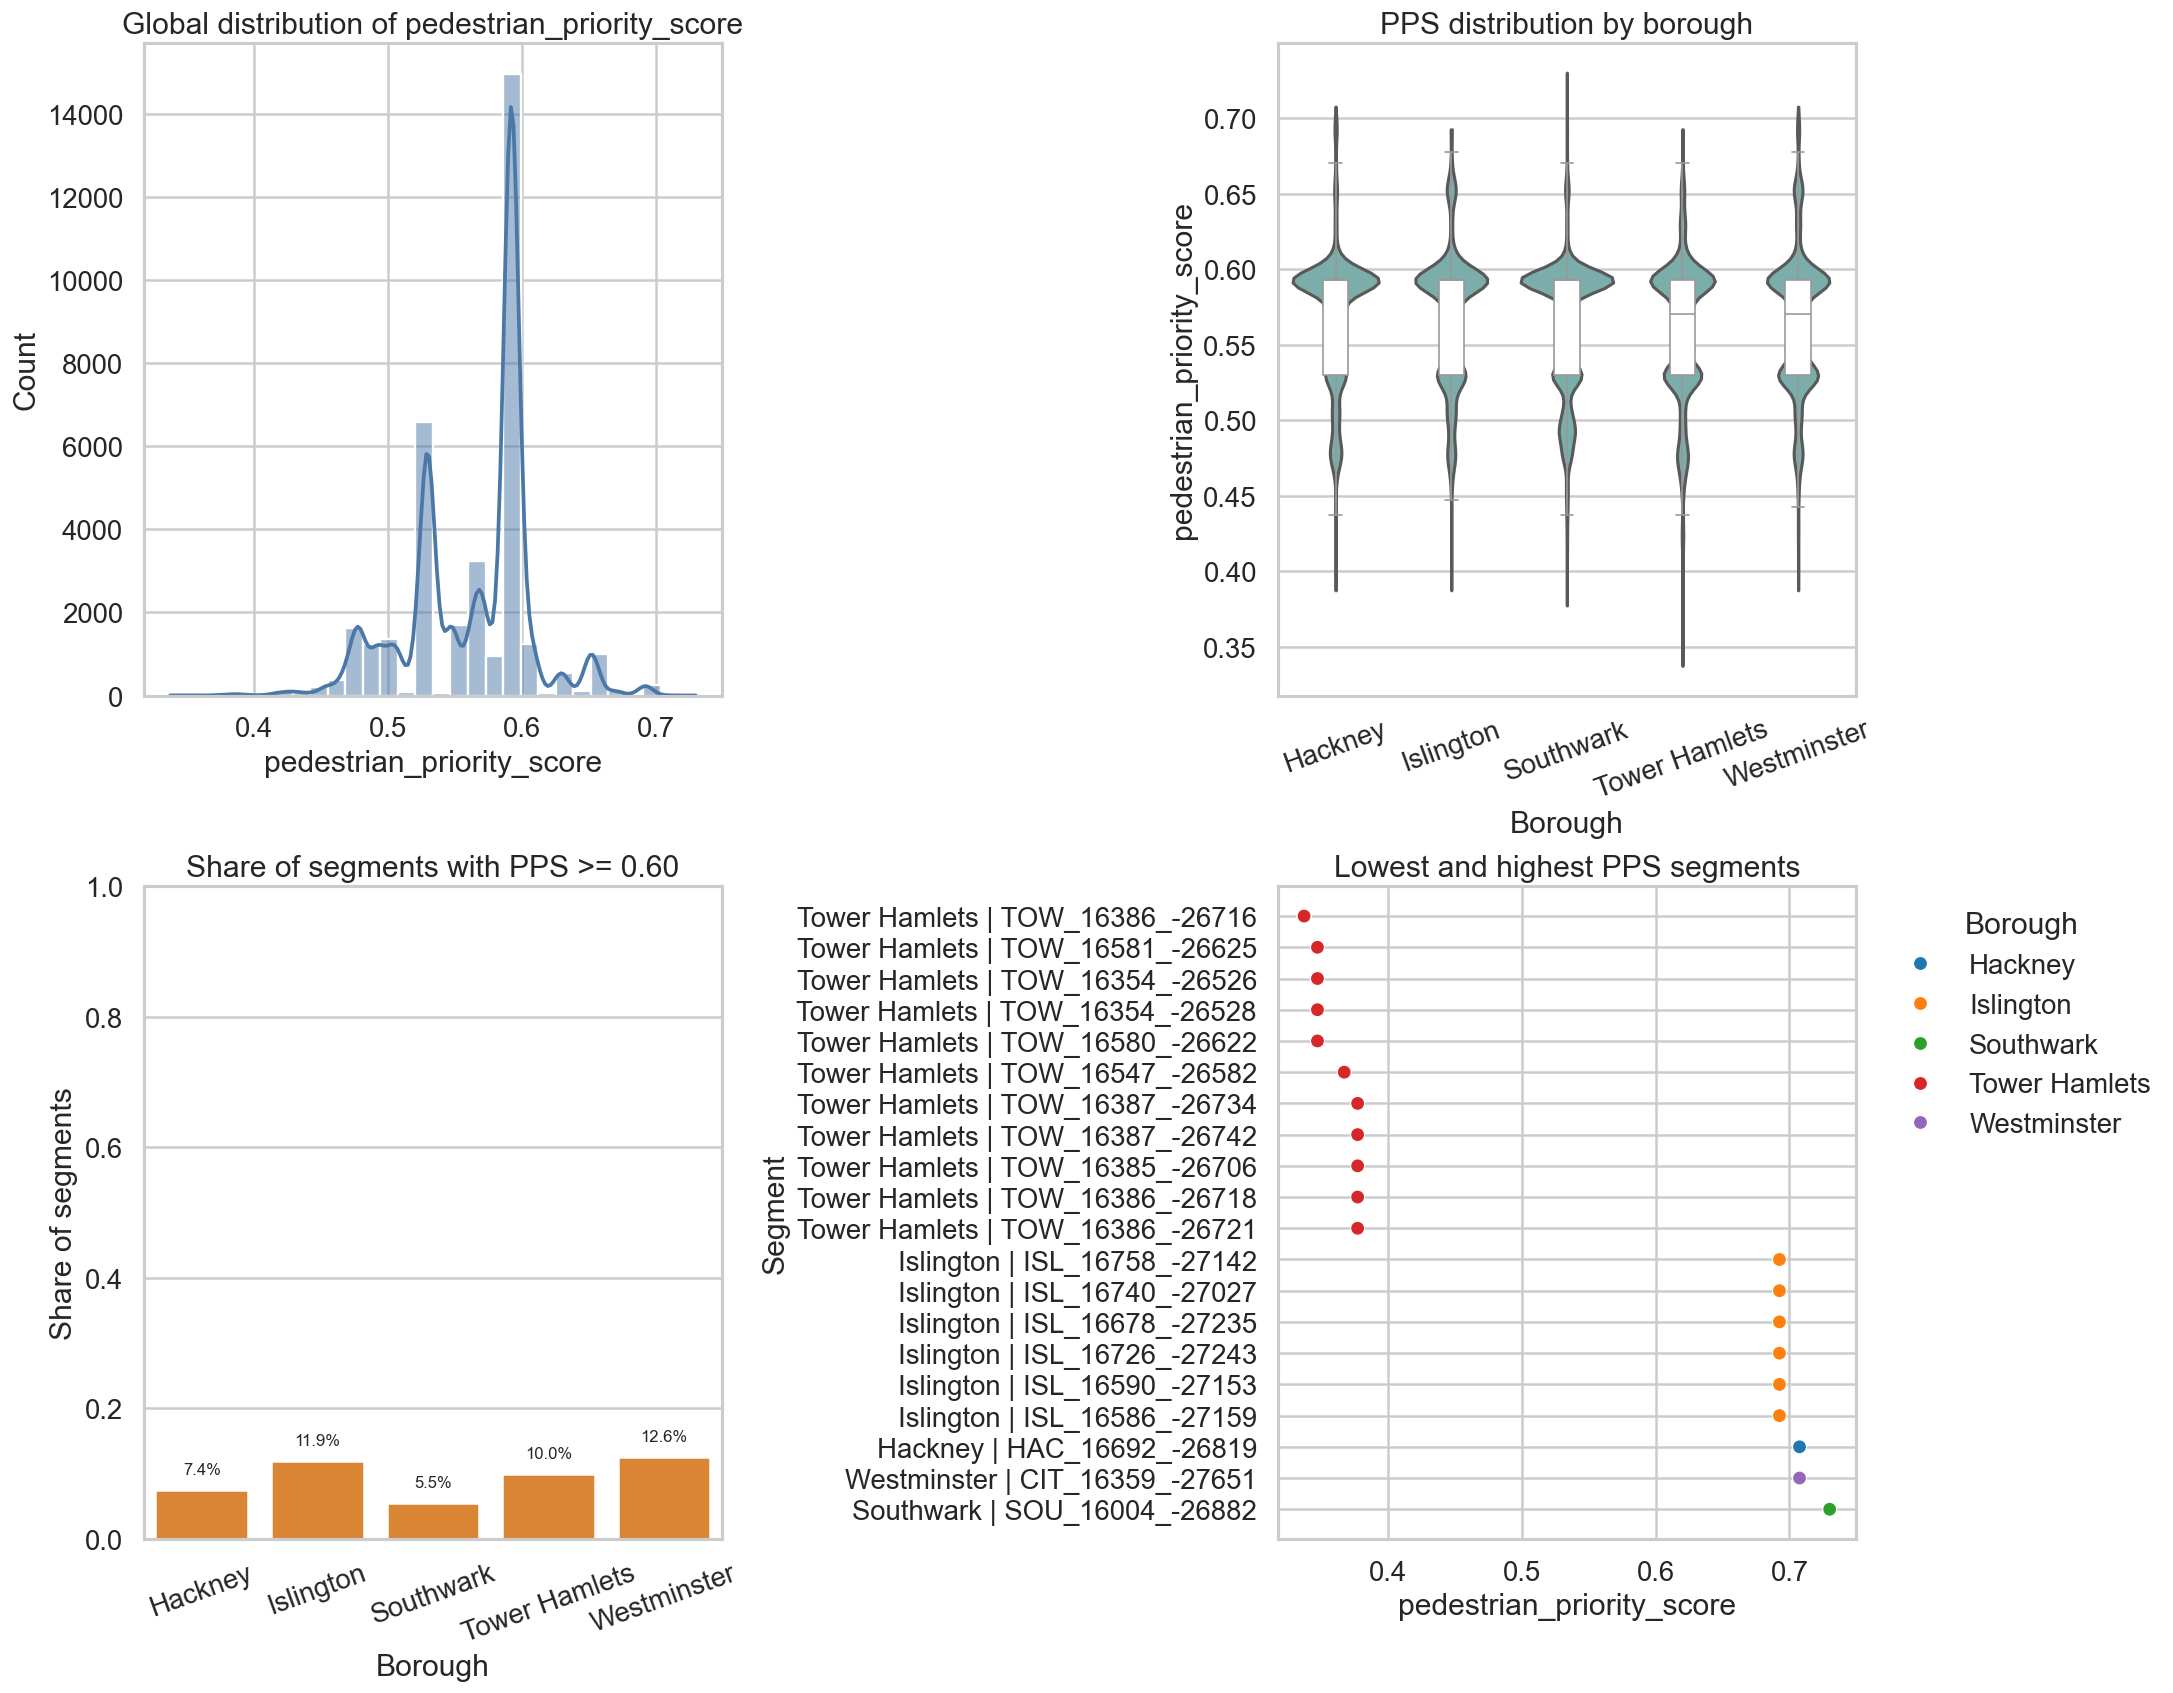

In [25]:
# ── PPS inspection plots ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = df.copy() if 'df' in globals() else pd.read_csv(OUTPUT_CSV)
if 'borough' not in plot_df.columns:
    raise ValueError('Expected a borough column in the PPS CSV for plotting.')

borough_labels = {
    'City of Westminster, London, UK': 'Westminster',
    'London Borough of Islington, London, UK': 'Islington',
    'London Borough of Hackney, London, UK': 'Hackney',
    'London Borough of Tower Hamlets, London, UK': 'Tower Hamlets',
    'London Borough of Southwark, London, UK': 'Southwark',
}

plot_df['borough_short'] = plot_df['borough'].map(borough_labels).fillna(plot_df['borough'])
borough_order = (
    plot_df.groupby('borough_short')['pedestrian_priority_score']
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 120

print(f'Loaded {len(plot_df):,} PPS rows from {OUTPUT_CSV.name}')
display(plot_df[['pedestrian_priority_score']].describe().T[['count', 'mean', 'min', 'max']])

threshold = 0.60
high_share = (
    plot_df.assign(is_high=plot_df['pedestrian_priority_score'] >= threshold)
    .groupby('borough_short')['is_high']
    .mean()
    .reindex(borough_order)
)

extremes = pd.concat([
    plot_df.nsmallest(12, 'pedestrian_priority_score'),
    plot_df.nlargest(12, 'pedestrian_priority_score'),
], ignore_index=True)
extremes = extremes.sort_values('pedestrian_priority_score').copy()
extremes['segment_label'] = (
    extremes['borough_short'].astype(str)
    + ' | '
    + extremes['location_id'].astype(str)
)

fig, axes = plt.subplots(2, 2, figsize=(18, 14), constrained_layout=True)
axes = axes.flatten()

sns.histplot(plot_df['pedestrian_priority_score'], bins=30, kde=True, ax=axes[0], color='#4C78A8')
axes[0].set_title('Global distribution of pedestrian_priority_score')
axes[0].set_xlabel('pedestrian_priority_score')
axes[0].set_ylabel('Count')

sns.violinplot(
    data=plot_df,
    x='borough_short',
    y='pedestrian_priority_score',
    order=borough_order,
    ax=axes[1],
    inner=None,
    cut=0,
    color='#72B7B2',
)
sns.boxplot(
    data=plot_df,
    x='borough_short',
    y='pedestrian_priority_score',
    order=borough_order,
    ax=axes[1],
    width=0.22,
    showfliers=False,
    color='white',
)
axes[1].set_title('PPS distribution by borough')
axes[1].set_xlabel('Borough')
axes[1].set_ylabel('pedestrian_priority_score')
axes[1].tick_params(axis='x', rotation=20)

sns.barplot(x=high_share.index, y=high_share.values, ax=axes[2], color='#F58518')
axes[2].set_title(f'Share of segments with PPS >= {threshold:.2f}')
axes[2].set_xlabel('Borough')
axes[2].set_ylabel('Share of segments')
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis='x', rotation=20)
for i, value in enumerate(high_share.values):
    axes[2].text(i, value + 0.02, f'{value:.1%}', ha='center', va='bottom', fontsize=10)

sns.scatterplot(
    data=extremes,
    x='pedestrian_priority_score',
    y='segment_label',
    hue='borough_short',
    hue_order=borough_order,
    palette='tab10',
    s=70,
    ax=axes[3],
)
axes[3].set_title('Lowest and highest PPS segments')
axes[3].set_xlabel('pedestrian_priority_score')
axes[3].set_ylabel('Segment')
axes[3].legend(title='Borough', frameon=False, loc='upper left', bbox_to_anchor=(1.02, 1))

plots_dir = REPO_ROOT / 'notebooks' / 'plots'
plots_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(plots_dir / 'pps_inspection_plots.png', bbox_inches='tight')

plt.show()
